# PCA + 二维适用域判断


流程：**全部训练数据拟合 PCA → 在训练 PCA 坐标中划分参考集/校准集 → 计算适用域 → 给目标 Excel 新增 `PCA_2D_AD` 列**。


## 1. 参数含义

- `K = 5`：使用第5近邻距离衡量局部训练覆盖；
- `ALPHA = 0.2`：经验校准范围为80%，`p > 0.2` 判为 `inside`；
- `CALIBRATION_SIZE = 0.25`：PCA 完成后，将25%的训练坐标用于校准阈值；
- `RANDOM_STATE = 42`：固定划分，确保结果可重复。


In [1]:
from copy import copy
from pathlib import Path
from shutil import copy2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

TRAIN_FILE = Path(r'D:\Users\lihao\Desktop\SanHuan\ML_code\EACOMP\data\data_923K_2026_09_09_v2.xlsx')
TARGET_FILE = Path(r'data/Liu_Meilin_AEM/650C_from刘美林_ASR_with_features.xlsx')
TRAIN_SHEET = 'features'
TARGET_SHEET = 'features'

EXCLUDE_COLS = ['Composition', 'Log_ASR']
MISSING_THRESHOLD = 0.40
K = 5
ALPHA = 0.2
CALIBRATION_SIZE = 0.2
RANDOM_STATE = 42

OUTPUT_COLUMN = 'PCA_2D_AD'
OUTPUT_FILE = TARGET_FILE.with_name(TARGET_FILE.stem + '_PCA_2D_AD.xlsx')


## 2. 读取训练数据和目标数据

选择两个工作表共有的数值特征。缺失率和常数特征判断基于全部训练数据，目标数据不参与任何拟合。


In [2]:
train_df = pd.read_excel(TRAIN_FILE, sheet_name=TRAIN_SHEET)
target_df = pd.read_excel(TARGET_FILE, sheet_name=TARGET_SHEET)

common_features = [
    c for c in train_df.columns
    if c not in EXCLUDE_COLS and c in target_df.columns
]
non_numeric = [
    c for c in common_features
    if not pd.api.types.is_numeric_dtype(train_df[c])
    or not pd.api.types.is_numeric_dtype(target_df[c])
]
if non_numeric:
    raise ValueError(f'共同特征中存在非数值列：{non_numeric}')

missing_rate = train_df[common_features].isna().mean()
drop_missing = missing_rate[missing_rate > MISSING_THRESHOLD].index.tolist()
feature_cols = [c for c in common_features if c not in drop_missing]
constant_cols = [c for c in feature_cols if train_df[c].nunique(dropna=True) <= 1]
feature_cols = [c for c in feature_cols if c not in constant_cols]

if len(feature_cols) < 2:
    raise ValueError('可用于 PCA 的共同数值特征少于2个。')

print(f'训练样本：{len(train_df)}')
print(f'目标样本：{len(target_df)}')
print(f'最终 PCA 特征数：{len(feature_cols)}')
print(f'缺失率过高删除：{drop_missing}')
print(f'常数特征删除：{constant_cols}')


训练样本：482
目标样本：143
最终 PCA 特征数：25
缺失率过高删除：[]
常数特征删除：[]


## 3. 用全部训练样本拟合二维 PCA

缺失值填补、原始特征标准化和 PCA 均使用全部训练数据拟合。


In [3]:
imputer = SimpleImputer(strategy='median')
feature_scaler = StandardScaler()
pca = PCA(n_components=2)

X_train = imputer.fit_transform(train_df[feature_cols])
X_target = imputer.transform(target_df[feature_cols])
X_train_z = feature_scaler.fit_transform(X_train)
X_target_z = feature_scaler.transform(X_target)

train_scores = pca.fit_transform(X_train_z)
target_scores = pca.transform(X_target_z)

print(f'PC1 解释方差：{pca.explained_variance_ratio_[0] * 100:.2f}%')
print(f'PC2 解释方差：{pca.explained_variance_ratio_[1] * 100:.2f}%')
print(f'累计解释方差：{pca.explained_variance_ratio_.sum() * 100:.2f}%')


PC1 解释方差：48.89%
PC2 解释方差：15.51%
累计解释方差：64.39%


## 4. PCA 后再划分参考集和校准集

全部349个训练样本已经位于同一个固定的 PCA 空间中。随后再划分：

- 参考集：建立 kNN；
- 校准集：计算第5近邻距离分布和 $D_{lim}$。

PC1、PC2 在计算距离前再次标准化，避免 PC1 方差较大而支配距离。


In [4]:
reference_idx, calibration_idx = train_test_split(
    np.arange(len(train_df)), test_size=CALIBRATION_SIZE,
    shuffle=True, random_state=RANDOM_STATE,
)
reference_scores = train_scores[reference_idx]
calibration_scores = train_scores[calibration_idx]

pc_scaler = StandardScaler()
reference_pc_z = pc_scaler.fit_transform(reference_scores)
calibration_pc_z = pc_scaler.transform(calibration_scores)
target_pc_z = pc_scaler.transform(target_scores)

knn = NearestNeighbors(n_neighbors=K).fit(reference_pc_z)
calibration_distance = knn.kneighbors(calibration_pc_z)[0][:, -1]
target_distance = knn.kneighbors(target_pc_z)[0][:, -1]

try:
    D_LIM = float(np.quantile(calibration_distance, 1 - ALPHA, method='higher'))
except TypeError:
    D_LIM = float(np.quantile(calibration_distance, 1 - ALPHA, interpolation='higher'))

target_p = (
    1 + (calibration_distance[None, :] >= target_distance[:, None]).sum(axis=1)
) / (len(calibration_distance) + 1)
inside = target_p > ALPHA
domain_label = np.where(inside, 'inside', 'outside')

print(f'参考/校准样本：{len(reference_idx)}/{len(calibration_idx_idx_idx) if False else len(calibration_idx)}')
print(f'D_lim = {D_LIM:.6f}')
print(f'inside：{inside.sum()}')
print(f'outside：{(~inside).sum()}')

pd.DataFrame({
    'Composition': target_df['Composition'] if 'Composition' in target_df else target_df.index,
    'PCA_2D_AD': domain_label,
})


参考/校准样本：385/97
D_lim = 0.176705
inside：83
outside：60


,Composition,PCA_2D_AD
0,Ba0.5Pr0.5Co0.9375Bi0.0625O3,outside
1,Ba0.5Pr0.5Co0.9375Ce0.0625O3,outside
2,Ba0.5Pr0.5Co0.9375Ga0.0625O3,outside
3,Ba0.5Pr0.5Co0.9375Hf0.0625O3,outside
4,Ba0.5Pr0.5Co0.9375In0.0625O3,outside
...,...,...
138,BaFe0.5Yb0.5O3,outside
139,BaFe0.75Zr0.25O3,inside
140,BaFe0.5Zr0.5O3,inside
141,Ba0.5Pr0.5CoO3,outside


## 5. 二维适用域图

绿色区域为 `inside`，灰色区域为 `outside`。图仅显示在 notebook 中，不保存为额外文件。


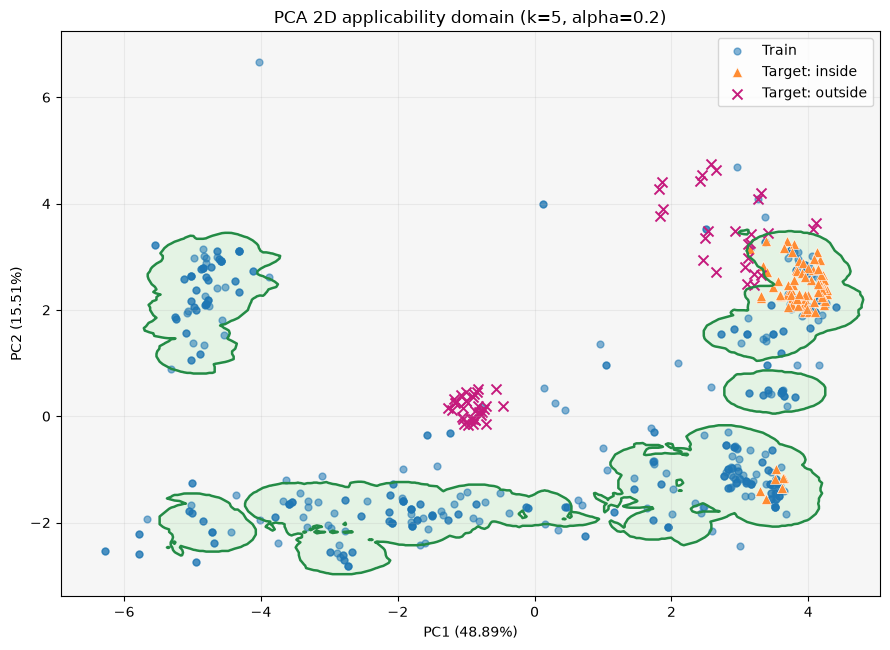

In [5]:
x_min = min(train_scores[:, 0].min(), target_scores[:, 0].min())
x_max = max(train_scores[:, 0].max(), target_scores[:, 0].max())
y_min = min(train_scores[:, 1].min(), target_scores[:, 1].min())
y_max = max(train_scores[:, 1].max(), target_scores[:, 1].max())
x_pad = 0.06 * (x_max - x_min)
y_pad = 0.06 * (y_max - y_min)
gx, gy = np.meshgrid(
    np.linspace(x_min - x_pad, x_max + x_pad, 260),
    np.linspace(y_min - y_pad, y_max + y_pad, 220),
)
grid_scores = np.column_stack([gx.ravel(), gy.ravel()])
grid_distance = knn.kneighbors(pc_scaler.transform(grid_scores))[0][:, -1]
grid_p = (
    1 + (calibration_distance[None, :] >= grid_distance[:, None]).sum(axis=1)
) / (len(calibration_distance) + 1)
grid_p = grid_p.reshape(gx.shape)

fig, ax = plt.subplots(figsize=(9, 6.6))
ax.contourf(gx, gy, grid_p, levels=[0, ALPHA, 1], colors=['#f3f3f3', '#dcefdc'], alpha=0.75)
ax.contour(gx, gy, grid_p, levels=[ALPHA], colors=['#238b45'], linewidths=1.8)
ax.scatter(train_scores[:, 0], train_scores[:, 1], s=24, alpha=0.55, label='Train')
ax.scatter(target_scores[inside, 0], target_scores[inside, 1], marker='^', s=52,
           color='#ff8c33', edgecolor='white', linewidth=0.4, label='Target: inside')
ax.scatter(target_scores[~inside, 0], target_scores[~inside, 1], marker='x', s=52,
           color='#c51b7d', linewidth=1.4, label='Target: outside')
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)',
       title=f'PCA 2D applicability domain (k={K}, alpha={ALPHA:g})')
ax.grid(alpha=0.20)
ax.legend(loc='best')
fig.tight_layout()
plt.show()


## 6. 输出新的 Excel 并记录结果

在 `features` 工作表末尾新增 `PCA_2D_AD`，记录该数据是否属于域内。


In [6]:
copy2(TARGET_FILE, OUTPUT_FILE)
wb = load_workbook(OUTPUT_FILE)
ws = wb[TARGET_SHEET]

headers = [ws.cell(1, c).value for c in range(1, ws.max_column + 1)]
output_col = headers.index(OUTPUT_COLUMN) + 1 if OUTPUT_COLUMN in headers else ws.max_column + 1
header_cell = ws.cell(1, output_col, OUTPUT_COLUMN)

if output_col > 1:
    source_header = ws.cell(1, output_col - 1)
    for attr in ['font', 'fill', 'border', 'alignment', 'protection']:
        setattr(header_cell, attr, copy(getattr(source_header, attr)))
    header_cell.number_format = source_header.number_format

if ws.max_row - 1 != len(domain_label):
    raise ValueError(f'Excel 数据行数与目标样本数不一致：{ws.max_row - 1} != {len(domain_label)}')

for excel_row, label in enumerate(domain_label, start=2):
    cell = ws.cell(excel_row, output_col, str(label))
    if output_col > 1:
        source_cell = ws.cell(excel_row, output_col - 1)
        for attr in ['font', 'fill', 'border', 'alignment', 'protection']:
            setattr(cell, attr, copy(getattr(source_cell, attr)))
        cell.number_format = 'General'

ws.column_dimensions[get_column_letter(output_col)].width = max(14, len(OUTPUT_COLUMN) + 2)
if ws.auto_filter.ref:
    ws.auto_filter.ref = f'A1:{get_column_letter(ws.max_column)}{ws.max_row}'
wb.save(OUTPUT_FILE)
print(f'输出文件：{OUTPUT_FILE.resolve()}')


输出文件：D:\Users\lihao\Desktop\SanHuan\ML_code\EACOMP\data\Liu_Meilin_AEM\650C_from刘美林_ASR_with_features_PCA_2D_AD.xlsx


## 7. 输出验证

检查工作表、结果列和样本数量。最终 Excel 增加域内/域外列


In [7]:
check_wb = load_workbook(OUTPUT_FILE, read_only=True, data_only=False)
check_ws = check_wb[TARGET_SHEET]
check_headers = [check_ws.cell(1, c).value for c in range(1, check_ws.max_column + 1)]
check_col = check_headers.index(OUTPUT_COLUMN) + 1
check_values = [check_ws.cell(r, check_col).value for r in range(2, check_ws.max_row + 1)]
verification = {
    'output_exists': OUTPUT_FILE.exists(),
    'sheets_preserved': check_wb.sheetnames,
    'result_column': OUTPUT_COLUMN,
    'target_rows': len(check_values),
    'inside': check_values.count('inside'),
    'outside': check_values.count('outside'),
    'contains_PCA_score_columns': any(str(h).startswith('PC') for h in check_headers if h != OUTPUT_COLUMN),
    'valid_labels_only': set(check_values) <= {'inside', 'outside'},
}
check_wb.close()
verification


{'output_exists': True,
 'sheets_preserved': ['features',
  'audit',
  'feature_definitions',
  'descriptor_table'],
 'result_column': 'PCA_2D_AD',
 'target_rows': 143,
 'inside': 83,
 'outside': 60,
 'contains_PCA_score_columns': False,
 'valid_labels_only': True}